# Skin Lesion — Data Preprocessing and MLP Training

**Student:** Your Name, Surname, StudentNumber

**Group:** Group 1 — Informatyka, Uczenie maszynowe

**Course:** Machine Learning

**Date:** 2026-06-02

This notebook prepares the HAM10000/ISIC training and test sets, preprocesses images for an MLP (no CNNs), trains a fully-connected network, and evaluates with confusion matrix and macro F1-score. The final cell is prepared for hidden-test evaluation by the instructor.

In [3]:
# Install any missing packages (uncomment if needed)
# !pip install tensorflow==2.14.0 scikit-learn pillow matplotlib plotly nbformat

import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import pickle

# Keras / TensorFlow imports
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [4]:
# Paths to metadata and image folders (adjust if needed)
TRAIN_META = 'data/HAM10000_metadata'
TEST_META = 'data/ISIC2018_Task3_Test_GroundTruth.csv'
TRAIN_FOLDERS = ['data/HAM10000_images_part_1', 'data/HAM10000_images_part_2']
TEST_FOLDER = 'data/ISIC2018_Task3_Test_Images'

# Load CSVs
train_df = pd.read_csv(TRAIN_META)
test_df = pd.read_csv(TEST_META)

# Show columns and sample rows
print(train_df.columns.tolist())
train_df.head()

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [5]:
import glob

# Map image paths
image_paths = {}
for folder in TRAIN_FOLDERS:
    for f in glob.glob(os.path.join(folder, '*.jpg')):
        image_id = os.path.splitext(os.path.basename(f))[0]
        image_paths[image_id] = f

test_image_paths = {}
for f in glob.glob(os.path.join(TEST_FOLDER, '*.jpg')):
    image_id = os.path.splitext(os.path.basename(f))[0]
    test_image_paths[image_id] = f

train_df['path'] = train_df['image_id'].map(image_paths.get)
test_df['path'] = test_df['image_id'].map(test_image_paths.get)

# Remove rows where path is missing
train_df = train_df.dropna(subset=['path'])
test_df = test_df.dropna(subset=['path'])

# Map to 3 classes
def map_labels(dx):
    if dx == 'nv':
        return 0 # Melanocytic nevi
    elif dx == 'mel':
        return 1 # Melanoma
    else:
        return 2 # Others

train_df['label'] = train_df['dx'].apply(map_labels)
test_df['label'] = test_df['dx'].apply(map_labels)

print("Train label distribution:\n", train_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())


Train label distribution:
 label
0    6705
2    2197
1    1113
Name: count, dtype: int64
Test label distribution:
 label
0    908
2    432
1    171
Name: count, dtype: int64


In [6]:
# Resize parameters
IMG_WIDTH = 48
IMG_HEIGHT = 48

def load_and_preprocess_images(df):
    images = []
    labels = []
    
    for idx, row in df.iterrows():
        try:
            img = Image.open(row['path']).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            img_arr = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_arr)
            labels.append(row['label'])
        except Exception as e:
            print(f"Error loading {row['path']}: {e}")
            
    return np.array(images), np.array(labels)

print("Loading training images...")
X_train, y_train = load_and_preprocess_images(train_df)

print("Loading testing images...")
X_test, y_test = load_and_preprocess_images(test_df)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("X_train shape:", X_train.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

Loading training images...
Loading testing images...
X_train shape: (10015, 48, 48, 3)
y_train_cat shape: (10015, 3)
X_test shape: (1511, 48, 48, 3)
y_test_cat shape: (1511, 3)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Split into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

# Compute class weights for unbalanced classes
y_train_labels = np.argmax(y_train_split, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Train split shape:", X_train_split.shape)
print("Val split shape:", X_val_split.shape)
print("Class weights:", class_weight_dict)

Train split shape: (8012, 48, 48, 3)
Val split shape: (2003, 48, 48, 3)
Class weights: {0: np.float64(0.4978871488938603), 1: np.float64(3.000749063670412), 2: np.float64(1.5191505498672735)}


In [8]:
from tensorflow.keras.layers import Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Model Design (MLP architecture - No CNNs)
model = Sequential([
    Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    Flatten(),
    
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 6912)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,539,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,690,755 (14.08 MB)

 Trainable params: 3,689,091 (14.07 MB)

 Non-trainable params: 1,664 (6.50 KB)

Starting training...
Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5247 - loss: 1.1004 - val_accuracy: 0.7044 - val_loss: 0.9824
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5678 - loss: 0.9517 - val_accuracy: 0.6201 - val_loss: 0.8340
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5960 - loss: 0.8998 - val_accuracy: 0.6106 - val_loss: 0.8657
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6115 - loss: 0.8550 - val_accuracy: 0.5686 - val_loss: 0.8618
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6187 - loss: 0.8329 - val_accuracy: 0.6405 - val_loss: 0.7380
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6155 - loss: 0.8192 - val_accuracy: 0.6316 - val_loss: 0.7832
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6233 - loss: 0.8033 - val_accuracy: 0.6340 - val_loss: 0.8180
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6319 - lo

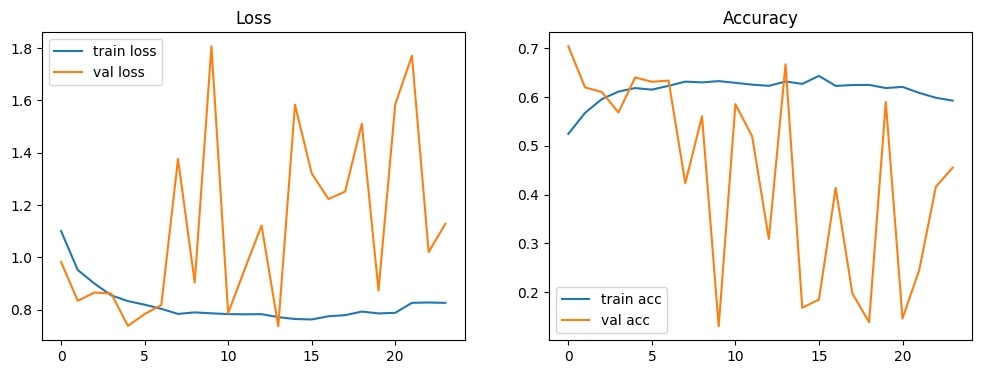

In [9]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mlp_model.keras', monitor='val_loss', save_best_only=True)

EPOCHS = 50
BATCH_SIZE = 64

print("Starting training...")
# Train the model with class weights
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()
plt.show()

Evaluating on the test set...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report:
                      precision    recall  f1-score   support

Melanocytic nevi (0)       0.70      0.81      0.75       908
        Melanoma (1)       0.31      0.35      0.33       171
          Others (2)       0.53      0.32      0.40       432

            accuracy                           0.62      1511
           macro avg       0.52      0.50      0.50      1511
        weighted avg       0.61      0.62      0.60      1511

Weighted F1-score: 0.6047
Macro F1-score: 0.4955

Confusion Matrix:
[[739  70  99]
 [ 87  60  24]
 [231  61 140]]


<Figure size 640x480 with 0 Axes>

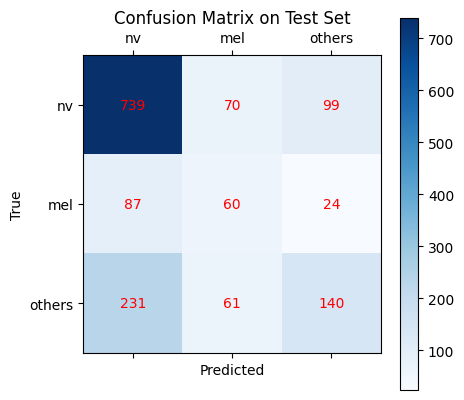

In [10]:
# Load the best model
best_model = load_model('best_mlp_model.keras')

# Predict on test set
print("Evaluating on the test set...")
y_pred_probs = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Evaluate using classification report
print("\nClassification Report:")
target_names = ['Melanocytic nevi (0)', 'Melanoma (1)', 'Others (2)']
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# Macro & Weighted F1-score
f1_weighted = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro = f1_score(y_test, y_pred_classes, average='macro')
print(f"Weighted F1-score: {f1_weighted:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure()
plt.matshow(cm, cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, ['nv', 'mel', 'others'])
plt.yticks(tick_marks, ['nv', 'mel', 'others'])
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="red")
plt.title('Confusion Matrix on Test Set')
plt.show()

---
# Final Evaluation Cell
*The cell below is prepared for the instructor to evaluate the final model on an unseen hidden dataset.*

*Please ensure you set the `HIDDEN_TEST_CSV` and `HIDDEN_TEST_IMG_DIR` variables accordingly.*

In [ ]:
# ==========================================
# HIDDEN TEST SET EVALUATION
# ==========================================
HIDDEN_TEST_CSV = 'path/to/hidden_test_labels.csv' 
HIDDEN_TEST_IMG_DIR = 'path/to/hidden_test_images'

def evaluate_hidden_dataset(csv_path, img_dir, model_path='best_mlp_model.keras'):
    try:
        final_model = load_model(model_path)
        hidden_df = pd.read_csv(csv_path)
        
        # Load and preprocess
        images = []
        labels = []
        for idx, row in hidden_df.iterrows():
            img_path = os.path.join(img_dir, row['image_id'] + '.jpg')
            if not os.path.exists(img_path):
                continue
                
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                images.append(np.array(img) / 255.0)
                labels.append(map_labels(row['dx']))
            except Exception as e:
                print("Error loading:", img_path, e)
                
        X_hidden = np.array(images)
        y_hidden = np.array(labels)
        
        # Preds
        y_pred_probs = final_model.predict(X_hidden)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        print("\nClassification Report (Hidden Set):")
        print(classification_report(y_hidden, y_pred_classes, target_names=['nv (0)', 'mel (1)', 'others (2)']))
        
        f1_w = f1_score(y_hidden, y_pred_classes, average='weighted')
        print(f"Weighted F1-score: {f1_w:.4f}")
        
    except FileNotFoundError:
        print(f"File not found. Please provide valid paths for HIDDEN_TEST_CSV and HIDDEN_TEST_IMG_DIR.")

evaluate_hidden_dataset(HIDDEN_TEST_CSV, HIDDEN_TEST_IMG_DIR)